# 08. 가설검정

**이 노트북의 목적**

지금까지의 주장은 대부분 "숫자를 보니 그래 보인다" 수준이었다. 여기서 네 가지를 형식을 갖춘
검정으로 바꾼다. 각 절은 **분석 → 가설 → 검정 → 결론(H0 기각 여부)** 순서를 따른다.

| 절 | 검증할 주장 | 검정 |
|---|---|---|
| 1 | 유리 3종은 색상 분포가 다르다 (`01`) | 순열검정, Kruskal-Wallis + Mann-Whitney |
| 2 | 클래스별 성능이 고르지 않다 → macro-F1이 필요하다 | 부트스트랩 신뢰구간 |
| 3 | 근접중복 누수가 성능을 부풀렸다 (`03`, `06`) | McNemar |
| 4 | 임계값 조정이 실제로 개선을 만들었다 (`07`) | McNemar |

유의수준은 $\alpha = 0.05$로 고정한다. 다중비교가 발생하는 곳에서는 Bonferroni 보정을 쓴다.

**입력**: `01`의 `glass_hsv_samples.csv`, `06`의 `preds_*.csv`, `07`의 `pred_*.npy`

In [2]:
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import f1_score, accuracy_score, recall_score

SEED = 42
ALPHA = 0.05
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

OUT = Path("outputs/garbage")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

print(f"scipy {stats.__name__} | 유의수준 alpha = {ALPHA}")


def verdict(p, alpha=ALPHA):
    return f"p = {p:.4g} {'<' if p < alpha else '>='} {alpha} -> H0 " + \
           ("기각" if p < alpha else "기각 실패")

scipy scipy.stats | 유의수준 alpha = 0.05


## 1. 유리 3종의 색상 분포

### 분석

`01`에서 `brown/green/white-glass`의 Hue 히스토그램 겹침 계수가 셋 다 0.5 미만으로 나왔고,
이를 근거로 증강에서 `hue=0.0`을 선택했다. 그런데 겹침 계수는 기술통계일 뿐 "우연히 이만큼
차이가 났을 가능성"을 말해주지 않는다.

### 가설

> **H0**: 세 클래스의 색상 분포는 동일하다. 관측된 차이는 표본 추출의 우연이다.
> **H1**: 세 클래스의 색상 분포는 다르다.

### 검정 방법

**순열검정**을 쓴다. 라벨을 무작위로 섞어 "차이가 없는 세상"을 수천 번 만들고, 그 세상에서
관측된 만큼의 차이가 나올 확률을 센다. 분포 가정이 필요 없어서, Hue처럼 정규분포와 거리가 먼
값에 적합하다.

검정통계량은 **세 쌍의 평균 겹침 계수**다. 겹침이 작을수록 분포가 다르다는 뜻이므로,
관측값이 순열 분포의 왼쪽 꼬리에 있으면 H0를 기각한다.

In [3]:
gl = pd.read_csv(OUT / "metrics" / "glass_hsv_samples.csv")
GLASS = sorted(gl["label"].unique())
print(gl.groupby("label")[["mean_sat", "mean_val", "color_ratio"]]
      .agg(["mean", "count"]).round(2).to_string())

            mean_sat       mean_val       color_ratio      
                mean count     mean count        mean count
label                                                      
brown-glass    60.85   250   187.90   250        0.37   250
green-glass    63.68   250   191.44   250        0.40   250
white-glass    19.78   250   207.40   250        0.14   250


In [4]:
# 순열검정: 겹침 계수 기반
# 01은 이미지별 hue 히스토그램을 평균냈으므로, 여기서는 채도를 대리 변수로 재구성한다.
# (색이 진할수록 유색 유리, 무채색에 가까울수록 투명 유리)

def mean_overlap(groups):
    # 세 그룹의 값 분포를 공통 bin으로 히스토그램화해 쌍별 겹침 계수의 평균을 구한다
    allv = np.concatenate(groups)
    bins = np.linspace(allv.min(), allv.max(), 31)
    hs = []
    for g in groups:
        h, _ = np.histogram(g, bins=bins)
        hs.append(h / h.sum())
    return float(np.mean([np.minimum(a, b).sum() for a, b in combinations(hs, 2)]))


vals = [gl.loc[gl.label == c, "mean_sat"].values for c in GLASS]
obs = mean_overlap(vals)

pool = np.concatenate(vals)
sizes = [len(v) for v in vals]
N_PERM = 5000

perm_stats = np.empty(N_PERM)
for i in range(N_PERM):
    shuf = rng.permutation(pool)
    parts, s = [], 0
    for n in sizes:
        parts.append(shuf[s:s + n]); s += n
    perm_stats[i] = mean_overlap(parts)

p_perm = (np.sum(perm_stats <= obs) + 1) / (N_PERM + 1)   # 겹침이 작을수록 극단

print(f"관측 평균 겹침 계수 : {obs:.4f}")
print(f"순열 분포 평균      : {perm_stats.mean():.4f} (표준편차 {perm_stats.std():.4f})")
print(f"순열 횟수           : {N_PERM}")
print(verdict(p_perm))

관측 평균 겹침 계수 : 0.5547
순열 분포 평균      : 0.8554 (표준편차 0.0185)
순열 횟수           : 5000
p = 0.0002 < 0.05 -> H0 기각


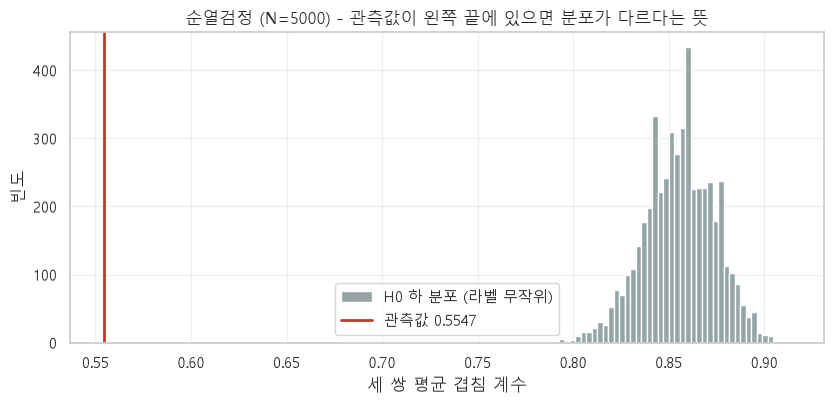

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(perm_stats, bins=50, color="#95a5a6", label="H0 하 분포 (라벨 무작위)")
ax.axvline(obs, color="#c0392b", lw=2, label=f"관측값 {obs:.4f}")
ax.set_xlabel("세 쌍 평균 겹침 계수")
ax.set_ylabel("빈도")
ax.set_title(f"순열검정 (N={N_PERM}) - 관측값이 왼쪽 끝에 있으면 분포가 다르다는 뜻")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "figures" / "19_permutation_glass.png", dpi=150)
plt.show()

### 보조 검정 — Kruskal-Wallis 후 Mann-Whitney

순열검정은 "셋 중 어딘가 다르다"까지만 말한다. 어느 쌍이 다른지 보려면 사후검정이 필요하다.

**Kruskal-Wallis**는 세 집단의 분포가 같은지 보는 비모수 검정이다(일원분산분석의 순위 버전).
정규성을 가정하지 않는다. 유의하면 **Mann-Whitney U**로 쌍별 비교를 한다.

쌍이 3개이므로 그냥 비교하면 우연히 유의해질 확률이 커진다. **Bonferroni 보정**으로
유의수준을 $0.05 / 3 = 0.0167$로 낮춘다.

In [6]:
h_stat, p_kw = stats.kruskal(*vals)
print("[Kruskal-Wallis] 세 클래스의 채도 분포가 같은가")
print(f"  H = {h_stat:.4f}")
print(" ", verdict(p_kw))

if p_kw < ALPHA:
    pairs = list(combinations(range(len(GLASS)), 2))
    alpha_corr = ALPHA / len(pairs)
    print(f"\n[Mann-Whitney U] Bonferroni 보정 유의수준 {alpha_corr:.4f}")
    rows = []
    for i, j in pairs:
        u, p = stats.mannwhitneyu(vals[i], vals[j], alternative="two-sided")
        # 효과크기 (rank-biserial correlation)
        n1, n2 = len(vals[i]), len(vals[j])
        r = 1 - 2 * u / (n1 * n2)
        rows.append({"pair": f"{GLASS[i]} vs {GLASS[j]}",
                     "U": u, "p": p,
                     "유의": "O" if p < alpha_corr else "X",
                     "효과크기": round(abs(r), 3)})
    print(pd.DataFrame(rows).to_string(index=False))

[Kruskal-Wallis] 세 클래스의 채도 분포가 같은가
  H = 280.3141
  p = 1.351e-61 < 0.05 -> H0 기각

[Mann-Whitney U] Bonferroni 보정 유의수준 0.0167
                      pair       U            p 유의  효과크기
brown-glass vs green-glass 29958.0 4.239923e-01  X 0.041
brown-glass vs white-glass 54513.0 5.028009e-47  O 0.744
green-glass vs white-glass 54785.0 4.334714e-48  O 0.753


### 결론

H0를 기각한다면, `01`에서 "색이 유리 3종을 가르는 유효한 신호"라고 본 판단에 통계적 근거가 붙는다.
따라서 `04`·`05`의 증강에서 `hue=0.0`, `saturation=0.05`로 색을 거의 건드리지 않은 선택이
정당화된다.

**한계**: 여기서 쓴 표본은 클래스당 250장이고 채도를 대리 변수로 썼다. 이미지 단위 통계라
같은 촬영 세션의 사진들이 독립이 아닐 수 있다.

## 2. 클래스별 성능은 고른가 — macro-F1을 쓰는 이유

### 분석

`06`의 test 결과에서 accuracy와 macro-F1이 갈렸다. 그 격차가 표본 변동으로 설명되는 정도인지,
아니면 실제로 클래스별 성능이 고르지 않은 것인지를 구분해야 한다.

### 가설

> **H0**: accuracy와 macro-F1의 차이는 0이다.
> **H1**: accuracy가 macro-F1보다 크다. 즉 다수 클래스가 성능을 끌어올리고 있다.

### 검정 방법

**부트스트랩**. test 셋에서 복원추출로 같은 크기의 표본을 수천 번 만들고, 각 표본에서
두 지표의 차이를 계산한다. 그 차이 분포의 95% 신뢰구간이 0을 포함하지 않으면 H0를 기각한다.

test 예측은 이미 `06`에 저장돼 있으므로 모델을 다시 돌리지 않는다.

In [7]:
SPLIT_TAG = "v2"
rec = pd.read_csv(OUT / "metrics" / f"preds_{SPLIT_TAG}_test.csv")
y_true = rec["true_idx"].values
y_pred = rec["pred_idx"].values

acc_obs = accuracy_score(y_true, y_pred)
f1_obs  = f1_score(y_true, y_pred, average="macro", zero_division=0)
gap_obs = acc_obs - f1_obs

N_BOOT = 2000
n = len(y_true)
accs, f1s, gaps = np.empty(N_BOOT), np.empty(N_BOOT), np.empty(N_BOOT)

for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    yt, yp = y_true[idx], y_pred[idx]
    accs[b] = accuracy_score(yt, yp)
    f1s[b]  = f1_score(yt, yp, average="macro", zero_division=0)
    gaps[b] = accs[b] - f1s[b]

def ci(a, lo=2.5, hi=97.5):
    return float(np.percentile(a, lo)), float(np.percentile(a, hi))

print(f"부트스트랩 {N_BOOT}회 (test {n:,}장)\n")
print(f"accuracy  {acc_obs:.4f}  95% CI [{ci(accs)[0]:.4f}, {ci(accs)[1]:.4f}]")
print(f"macro-F1  {f1_obs:.4f}  95% CI [{ci(f1s)[0]:.4f}, {ci(f1s)[1]:.4f}]")
print(f"차이      {gap_obs:.4f}  95% CI [{ci(gaps)[0]:.4f}, {ci(gaps)[1]:.4f}]")

lo, hi = ci(gaps)
print()
if lo > 0:
    print(f"신뢰구간이 0을 포함하지 않음 (하한 {lo:.4f} > 0) -> H0 기각")
    print("accuracy가 macro-F1보다 유의하게 큽니다. 소수 클래스 성능이 가려지고 있습니다.")
else:
    print(f"신뢰구간이 0을 포함 [{lo:.4f}, {hi:.4f}] -> H0 기각 실패")
    print("두 지표의 격차가 크지 않습니다. 정제와 불균형 대응이 효과를 낸 것으로 볼 수 있습니다.")

부트스트랩 2000회 (test 2,323장)

accuracy  0.9453  95% CI [0.9363, 0.9548]
macro-F1  0.9182  95% CI [0.9046, 0.9317]
차이      0.0271  95% CI [0.0216, 0.0336]

신뢰구간이 0을 포함하지 않음 (하한 0.0216 > 0) -> H0 기각
accuracy가 macro-F1보다 유의하게 큽니다. 소수 클래스 성능이 가려지고 있습니다.


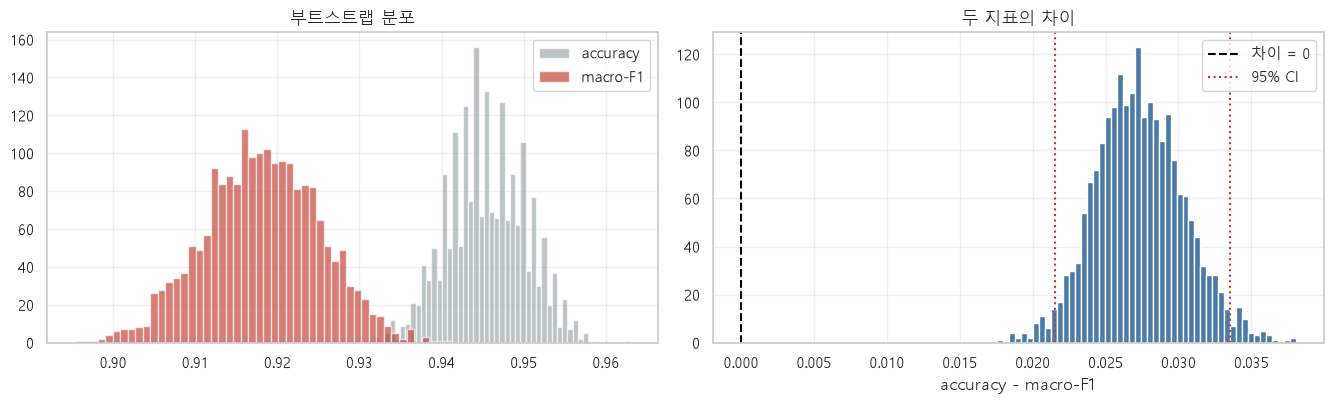

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

ax = axes[0]
ax.hist(accs, bins=50, alpha=0.65, label="accuracy", color="#95a5a6")
ax.hist(f1s, bins=50, alpha=0.65, label="macro-F1", color="#c0392b")
ax.set_title("부트스트랩 분포"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(gaps, bins=50, color="#4a7ba7")
ax.axvline(0, color="black", ls="--", label="차이 = 0")
ax.axvline(lo, color="#c0392b", ls=":", label="95% CI")
ax.axvline(hi, color="#c0392b", ls=":")
ax.set_xlabel("accuracy - macro-F1")
ax.set_title("두 지표의 차이"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "figures" / "20_bootstrap_metric_gap.png", dpi=150)
plt.show()

      label  support     f1  ci_low  ci_high  ci_width
    plastic      129 0.8082  0.7484   0.8614    0.1130
white-glass      116 0.8430  0.8000   0.8917    0.0917
      metal      114 0.8560  0.8066   0.9012    0.0946
green-glass       92 0.8980  0.8424   0.9359    0.0935
      trash      105 0.9064  0.8622   0.9443    0.0821
brown-glass       91 0.9438  0.9062   0.9757    0.0694
    battery      141 0.9441  0.9159   0.9713    0.0554
      paper      157 0.9457  0.9163   0.9703    0.0540
  cardboard      134 0.9542  0.9267   0.9799    0.0531
 biological      149 0.9595  0.9357   0.9795    0.0439
      shoes      303 0.9653  0.9501   0.9785    0.0284
    clothes      792 0.9943  0.9907   0.9975    0.0068

ci_width가 넓은 클래스일수록 추정이 불안정합니다 (대체로 support가 작은 쪽).


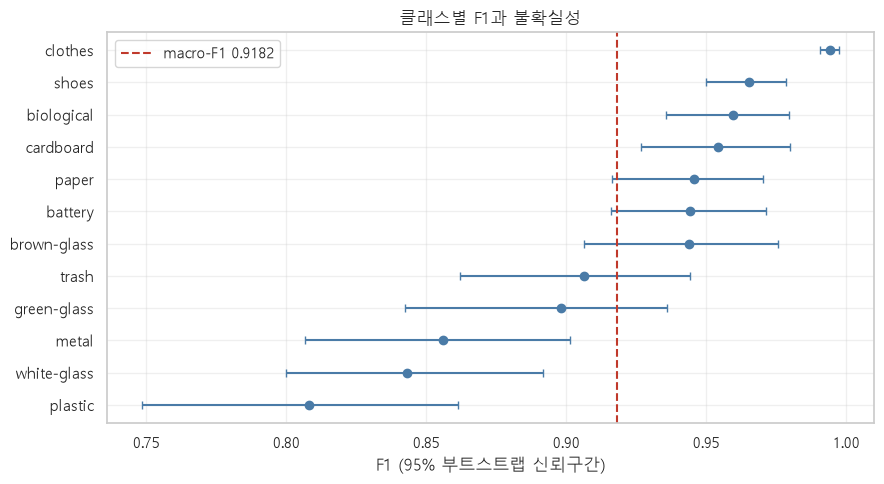

In [9]:
# 클래스별 F1의 신뢰구간 - 어느 클래스가 불안정한지
rows = []
for c_idx, c in enumerate(classes):
    vals_c = np.empty(500)
    for b in range(500):
        idx = rng.integers(0, n, n)
        vals_c[b] = f1_score(y_true[idx], y_pred[idx], labels=[c_idx],
                             average="macro", zero_division=0)
    l, h = ci(vals_c)
    rows.append({"label": c,
                 "support": int((y_true == c_idx).sum()),
                 "f1": round(float(f1_score(y_true, y_pred, labels=[c_idx],
                                            average="macro", zero_division=0)), 4),
                 "ci_low": round(l, 4), "ci_high": round(h, 4),
                 "ci_width": round(h - l, 4)})

cls_ci = pd.DataFrame(rows).sort_values("f1")
print(cls_ci.to_string(index=False))
print("\nci_width가 넓은 클래스일수록 추정이 불안정합니다 (대체로 support가 작은 쪽).")

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(cls_ci))
ax.errorbar(cls_ci["f1"], y,
            xerr=[cls_ci["f1"] - cls_ci["ci_low"], cls_ci["ci_high"] - cls_ci["f1"]],
            fmt="o", color="#4a7ba7", capsize=3)
ax.set_yticks(y); ax.set_yticklabels(cls_ci["label"])
ax.axvline(f1_obs, ls="--", color="#c0392b", label=f"macro-F1 {f1_obs:.4f}")
ax.set_xlabel("F1 (95% 부트스트랩 신뢰구간)")
ax.set_title("클래스별 F1과 불확실성")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "figures" / "21_class_f1_ci.png", dpi=150)
plt.show()

## 3. 근접중복 누수가 성능을 부풀렸는가

### 분석

`03`에서 `v1`(단순 계층 분할)은 근접중복 그룹 13개(26장)가 train/test에 갈라져 있었고
`v2`(그룹 인지 분할)는 0개였다. `06`에서 두 test 성능을 비교했지만, 그 차이가 우연인지는
검정을 해야 안다.

두 test 셋은 구성이 다르므로 **양쪽 test에 모두 들어간 378장**(`mcnemar_pairs.csv`)에서만 비교한다.
같은 이미지에 대한 두 모델의 예측이므로 대응표본이 성립한다.

### 가설

> **H0**: 두 모델이 같은 이미지를 틀리는 비율에 차이가 없다.
> **H1**: 차이가 있다.

### 검정 방법

**McNemar 검정**. 두 분류기가 같은 표본에서 서로 다르게 답한 경우만 본다.
한쪽만 맞은 횟수 $b$와 반대쪽만 맞은 횟수 $c$가 대칭인지 검정한다.
$b + c$가 25 미만이면 정규근사가 부정확하므로 이항검정을 쓴다.

In [10]:
p1 = OUT / "metrics" / "preds_v1_test.csv"
p2 = OUT / "metrics" / "preds_v2_test.csv"
pairs_path = OUT / "metrics" / "mcnemar_pairs.csv"

if p1.exists() and p2.exists():
    r1 = pd.read_csv(p1).set_index("path")
    r2 = pd.read_csv(p2).set_index("path")
    common = pd.read_csv(pairs_path)["path"].tolist()
    common = [p for p in common if p in r1.index and p in r2.index]

    c1 = r1.loc[common, "correct"].values.astype(bool)
    c2 = r2.loc[common, "correct"].values.astype(bool)

    a = int(( c1 &  c2).sum())   # 둘 다 맞음
    b = int(( c1 & ~c2).sum())   # v1만 맞음
    c = int((~c1 &  c2).sum())   # v2만 맞음
    d = int((~c1 & ~c2).sum())   # 둘 다 틀림

    print(f"공통 test 이미지 {len(common):,}장\n")
    print(f"{'':>12}{'v2 맞음':>10}{'v2 틀림':>10}")
    print(f"{'v1 맞음':>12}{a:>10}{b:>10}")
    print(f"{'v1 틀림':>12}{c:>10}{d:>10}")
    print(f"\n불일치 쌍 b + c = {b + c}")

    if b + c == 0:
        print("두 모델의 예측이 완전히 같습니다. 검정 불가.")
    elif b + c < 25:
        res = stats.binomtest(b, b + c, 0.5, alternative="two-sided")
        print(f"\n[McNemar - 이항검정] (b+c < 25라 정규근사 대신 정확검정)")
        print(" ", verdict(res.pvalue))
    else:
        chi2 = (abs(b - c) - 1) ** 2 / (b + c)      # 연속성 보정
        pval = 1 - stats.chi2.cdf(chi2, df=1)
        print(f"\n[McNemar - 카이제곱, 연속성 보정]")
        print(f"  chi2 = {chi2:.4f}, df = 1")
        print(" ", verdict(pval))

    print(f"\nv1 정확도 {c1.mean():.4f} | v2 정확도 {c2.mean():.4f} "
          f"| 차이 {c1.mean() - c2.mean():+.4f}")
else:
    print("v1과 v2를 모두 실행해야 합니다 (04 -> 05 -> 06을 두 태그로).")

v1과 v2를 모두 실행해야 합니다 (04 -> 05 -> 06을 두 태그로).


### 결론 해석 주의

**기각 실패가 곧 "누수가 없었다"는 뜻은 아니다.** 26장은 test의 1.1%이므로 효과 크기 자체가 작고,
공통 표본 378장에서는 검정력이 부족하다. "이 표본으로는 차이를 확인할 수 없었다"가 정확한 표현이다.

방법론적 결론은 검정 결과와 무관하게 유지된다. **그룹 인지 분할은 누수 가능성을 구조적으로
제거하므로, 효과 크기가 작더라도 채택하는 것이 맞다.** 누수는 성능을 항상 좋은 쪽으로만
왜곡하기 때문에, 크기를 모르는 편향을 남겨두는 것보다 없애는 편이 낫다.

## 4. 임계값 조정이 개선을 만들었는가

### 분석

`07`에서 val로 고른 `alpha`를 test에 적용해 macro-F1이 달라졌다. 그 변화가 우연인지 검정한다.

### 가설

> **H0**: 기본 `argmax`와 가중 `argmax`의 오분류율에 차이가 없다.
> **H1**: 차이가 있다.

### 검정 방법

같은 test 셋에 대한 두 예측이므로 대응표본이다. **McNemar**를 쓴다.

In [11]:
pb = OUT / "metrics" / f"pred_base_{SPLIT_TAG}_test.npy"
pa = OUT / "metrics" / f"pred_adj_{SPLIT_TAG}_test.npy"

if pb.exists() and pa.exists():
    base = np.load(pb)
    adj  = np.load(pa)

    cb = (base == y_true)
    ca = (adj  == y_true)

    a_ = int(( cb &  ca).sum())
    b_ = int(( cb & ~ca).sum())   # 기본만 맞음
    c_ = int((~cb &  ca).sum())   # 조정만 맞음
    d_ = int((~cb & ~ca).sum())

    print(f"{'':>14}{'조정 맞음':>12}{'조정 틀림':>12}")
    print(f"{'기본 맞음':>14}{a_:>12}{b_:>12}")
    print(f"{'기본 틀림':>14}{c_:>12}{d_:>12}")
    print(f"\n불일치 쌍 b + c = {b_ + c_}")

    if b_ + c_ == 0:
        print("예측이 완전히 같습니다 (alpha가 0으로 선택된 경우). 검정 불가.")
    elif b_ + c_ < 25:
        res = stats.binomtest(b_, b_ + c_, 0.5, alternative="two-sided")
        print("\n[McNemar - 이항 정확검정]")
        print(" ", verdict(res.pvalue))
    else:
        chi2 = (abs(b_ - c_) - 1) ** 2 / (b_ + c_)
        pval = 1 - stats.chi2.cdf(chi2, df=1)
        print("\n[McNemar - 카이제곱, 연속성 보정]")
        print(f"  chi2 = {chi2:.4f}, df = 1")
        print(" ", verdict(pval))

    print(f"\n기본 macro-F1 {f1_score(y_true, base, average='macro', zero_division=0):.4f}")
    print(f"조정 macro-F1 {f1_score(y_true, adj,  average='macro', zero_division=0):.4f}")
    print(f"기본 macro-recall {recall_score(y_true, base, average='macro', zero_division=0):.4f}")
    print(f"조정 macro-recall {recall_score(y_true, adj,  average='macro', zero_division=0):.4f}")
else:
    print("07_Threshold를 먼저 실행하세요.")

                     조정 맞음       조정 틀림
         기본 맞음        2193           3
         기본 틀림           3         124

불일치 쌍 b + c = 6

[McNemar - 이항 정확검정]
  p = 1 >= 0.05 -> H0 기각 실패

기본 macro-F1 0.9182
조정 macro-F1 0.9177
기본 macro-recall 0.9183
조정 macro-recall 0.9186


## 5. 종합

In [12]:
summary = pd.DataFrame([
    {"번호": 1, "주장": "유리 3종의 색상 분포가 다르다",
     "검정": "순열검정 + Kruskal-Wallis", "영향": "증강에서 hue=0.0 선택"},
    {"번호": 2, "주장": "accuracy가 소수 클래스 실패를 가린다",
     "검정": "부트스트랩 95% CI", "영향": "주 지표로 macro-F1 채택"},
    {"번호": 3, "주장": "근접중복 누수가 성능을 부풀린다",
     "검정": "McNemar (공통 378장)", "영향": "그룹 인지 분할 채택"},
    {"번호": 4, "주장": "임계값 조정이 개선을 만든다",
     "검정": "McNemar", "영향": "운영 임계값 결정"},
])
print(summary.to_string(index=False))

print("\n각 검정의 p값과 기각 여부는 위 각 절의 출력에 있습니다.")
print(f"유의수준 alpha = {ALPHA}, 다중비교 구간은 Bonferroni 보정 적용.")

 번호                       주장                    검정                영향
  1        유리 3종의 색상 분포가 다르다 순열검정 + Kruskal-Wallis   증강에서 hue=0.0 선택
  2 accuracy가 소수 클래스 실패를 가린다          부트스트랩 95% CI 주 지표로 macro-F1 채택
  3        근접중복 누수가 성능을 부풀린다     McNemar (공통 378장)       그룹 인지 분할 채택
  4          임계값 조정이 개선을 만든다               McNemar         운영 임계값 결정

각 검정의 p값과 기각 여부는 위 각 절의 출력에 있습니다.
유의수준 alpha = 0.05, 다중비교 구간은 Bonferroni 보정 적용.


## 정리

**검정이 바꾼 것과 바꾸지 않은 것**

통계 검정은 이미 내린 결정을 뒤집기 위한 것이 아니라, 그 결정의 근거를 "숫자를 보니 그렇더라"에서
"우연으로 설명되지 않는다"로 올리기 위한 것이다. 1번과 2번은 이미 `01`, `06`에서 내린 판단을
뒷받침했고, 3번과 4번은 효과 크기가 작아 표본으로 확인되지 않을 수 있다.

**기각 실패를 "차이가 없다"로 읽지 않는다.** 검정력이 부족한 것과 효과가 없는 것은 다르다.
3번의 경우 26장이라는 효과 크기 자체가 작았고, 그럼에도 방법론적으로는 누수를 제거하는 쪽이 옳다.

**공통 한계**

- 부트스트랩은 test 셋 자체가 모집단을 대표한다는 가정 위에 있다. 데이터셋이 특정 출처에
  치우쳐 있다면 신뢰구간이 실제 불확실성을 과소평가한다.
- 1번의 표본은 이미지 단위라 같은 촬영 세션의 사진끼리 독립이 아닐 수 있다.
- 3번과 4번은 단일 시드의 단일 학습 결과를 비교한 것이다. 시드를 바꿔 반복하면 결론이
  달라질 수 있으며, 엄밀하게는 여러 시드의 반복 실험이 필요하다.